## Phone Addiction Prediction — Kaggle Competition
**Problem.** Predict, for each user in the test set, the probability that they are "addicted" to their phone (addicted_label), based on usage and demographic features (screen time, social media/gaming hours, sleep, notifications, stress level, etc.).

**Data.** train.csv / test.csv from the Kaggle "Phone Addiction" competition. The training data contains around 691k rows with substantial missingness (up to ~20% in some columns) — this same missingness pattern exists in the test set, so I decided to handle it by the model rather than remove it.

**Metrics.** The [competition](https://www.kaggle.com/competitions/playground-series-s6e8/overview) scores submissions on the predicted probability of addiction, using ROC-AUC. For the evaluation I also used the Brier score, log loss and the calibration curve. The calibration curve takes the people the model gave a specific probability to, and shows how many of them were actually addicted. Log loss and the Brier score measure the same kind of error as a single number — they punish wrong predictions.

**Result.** Logistic regression is used as a baseline. XGBoost outperforms it, and — counter to what local cross-validation initially suggested — training XGBoost on the *full* dataset (letting it handle missing values natively) beats dropping incomplete rows, both locally and on the public leaderboard. After hyperparameter tuning with RandomizedSearchCV, the final model reaches **0.96463** public LB ROC-AUC.


In [1]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
import xgboost as xgb

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold,cross_val_predict, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import roc_auc_score, roc_curve, brier_score_loss, log_loss
from sklearn.calibration import calibration_curve
from sklearn.impute import SimpleImputer

import shap


/opt/homebrew/Caskroom/miniforge/base/envs/ds_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df= pd.read_csv('train.csv')
df.count()

id                         691369
age                        662440
daily_screen_time_hours    595515
social_media_hours         557374
gaming_hours               564548
work_study_hours           639851
sleep_hours                646889
notifications_per_day      623785
app_opens_per_day          610659
weekend_screen_time        579306
gender                     662335
stress_level               636221
academic_work_impact       647145
addicted_label             691369
dtype: int64

In [4]:
df.isnull().sum()

id                              0
age                         28929
daily_screen_time_hours     95854
social_media_hours         133995
gaming_hours               126821
work_study_hours            51518
sleep_hours                 44480
notifications_per_day       67584
app_opens_per_day           80710
weekend_screen_time        112063
gender                      29034
stress_level                55148
academic_work_impact        44224
addicted_label                  0
dtype: int64

In [5]:
df.describe()

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,addicted_label
count,691369.000000,662440.000000,595515.000000,557374.000000,564548.000000,639851.000000,646889.000000,623785.000000,610659.000000,579306.000000,691369.000000
mean,345684.000000,26.615408,7.640865,2.471038,1.459265,2.366971,6.804334,145.894900,102.636781,9.479866,0.709424
std,199581.183467,5.153162,2.721446,1.316137,0.934552,1.258797,1.234512,65.917556,48.093970,2.856006,0.454028
min,0.000000,18.000000,0.500000,0.000000,0.000000,0.000000,4.500000,20.000000,15.000000,0.510000,0.000000
25%,172842.000000,22.000000,5.480000,1.450000,0.700000,1.360000,5.780000,93.000000,64.000000,7.280000,0.000000
50%,345684.000000,27.000000,7.770000,2.310000,1.330000,2.200000,6.800000,150.000000,104.000000,9.580000,1.000000
75%,518526.000000,31.000000,9.840000,3.370000,2.090000,3.200000,7.870000,204.000000,145.000000,11.750000,1.000000
max,691368.000000,35.000000,15.000000,8.000000,4.000000,6.000000,9.000000,250.000000,180.000000,17.560000,1.000000


In [6]:
eda_df=df.drop(columns=['id'])


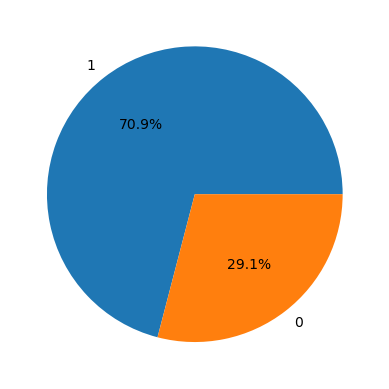

In [7]:
counts = eda_df['addicted_label'].value_counts()

fig, ax = plt.subplots()
ax.pie(counts.values, labels=counts.index, autopct='%1.1f%%')
plt.show()

<BarContainer object of 9 artists>

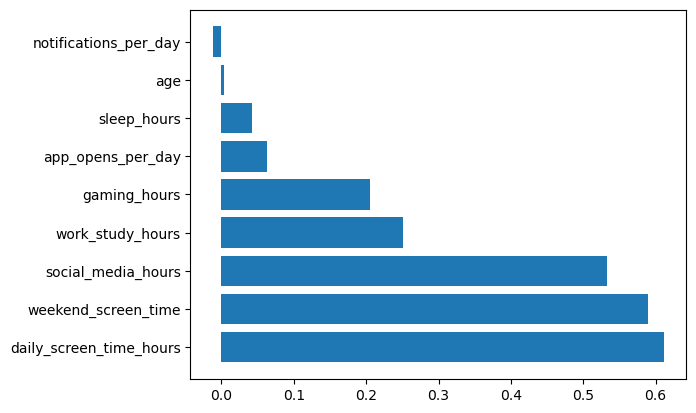

In [8]:
corr_matrix= eda_df.select_dtypes(include=[np.number]).corr()
addicted_corr = corr_matrix['addicted_label'].sort_values(ascending=False)[1:]
plt.barh(addicted_corr.index, addicted_corr.values)

<Axes: >

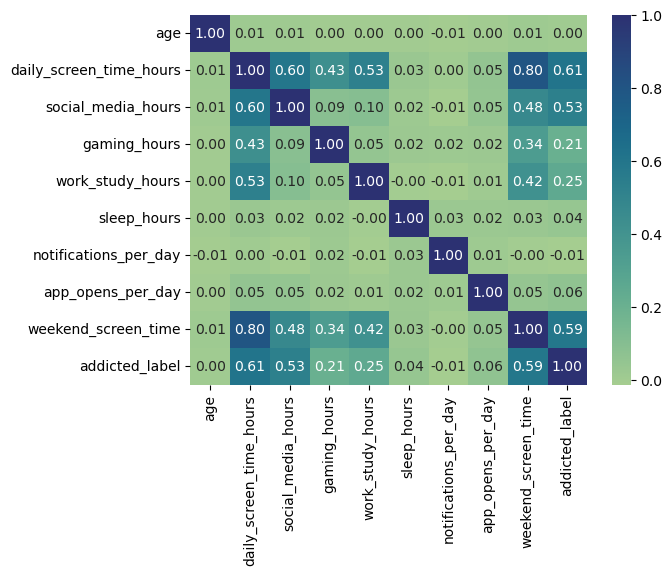

In [9]:

sns.heatmap(corr_matrix, cmap="crest", annot=True, fmt=".2f")

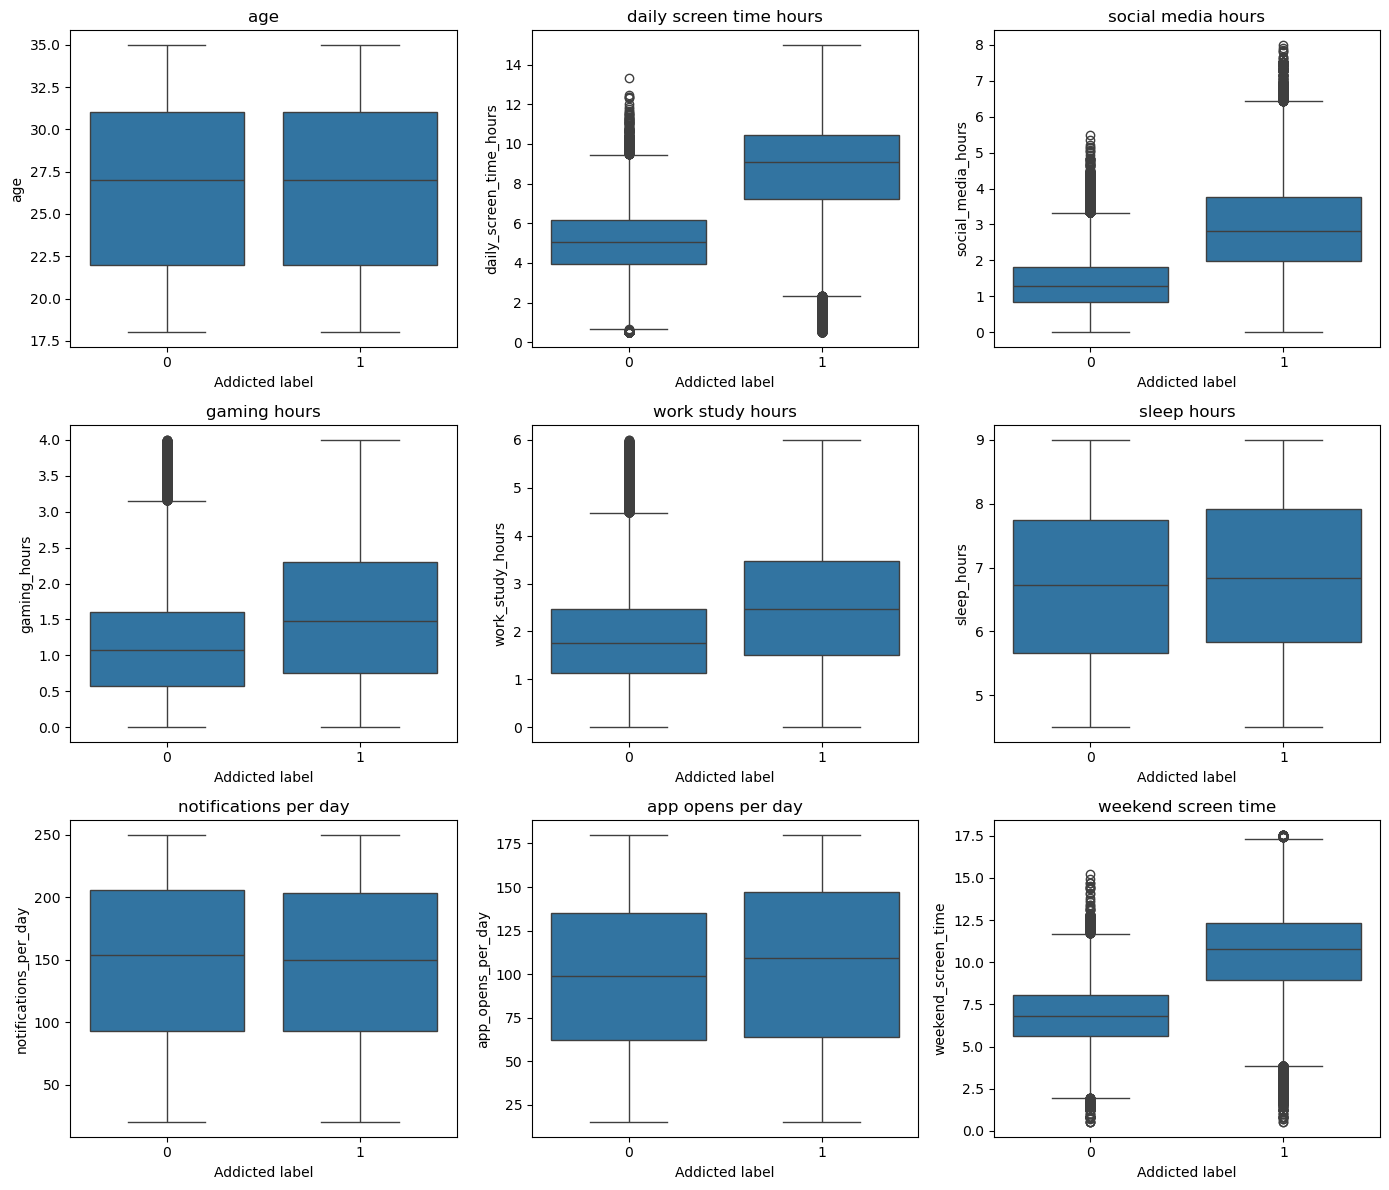

In [10]:
numerical_features = eda_df.drop('addicted_label', axis=1).select_dtypes(include="number").columns.to_list()

n = len(numerical_features)
fig, axes = plt.subplots(nrows=(n + 2) // 3, ncols=3, figsize=(14, 4 * ((n + 2) // 3)))
axes = axes.flatten()

for ax, col in zip(axes, numerical_features):
    sns.boxplot(data=df, x='addicted_label', y=col, ax=ax)
    ax.set_title(col.replace('_', ' '))
    ax.set_xlabel('Addicted label')

for ax in axes[n:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

As the boxplot shows, the biggest difference between phone addiction types is the daily screen time, social media hours. Age, notifications_per_day, app_opens_per_day, sleep hours have no difference between the two types according to the box plots

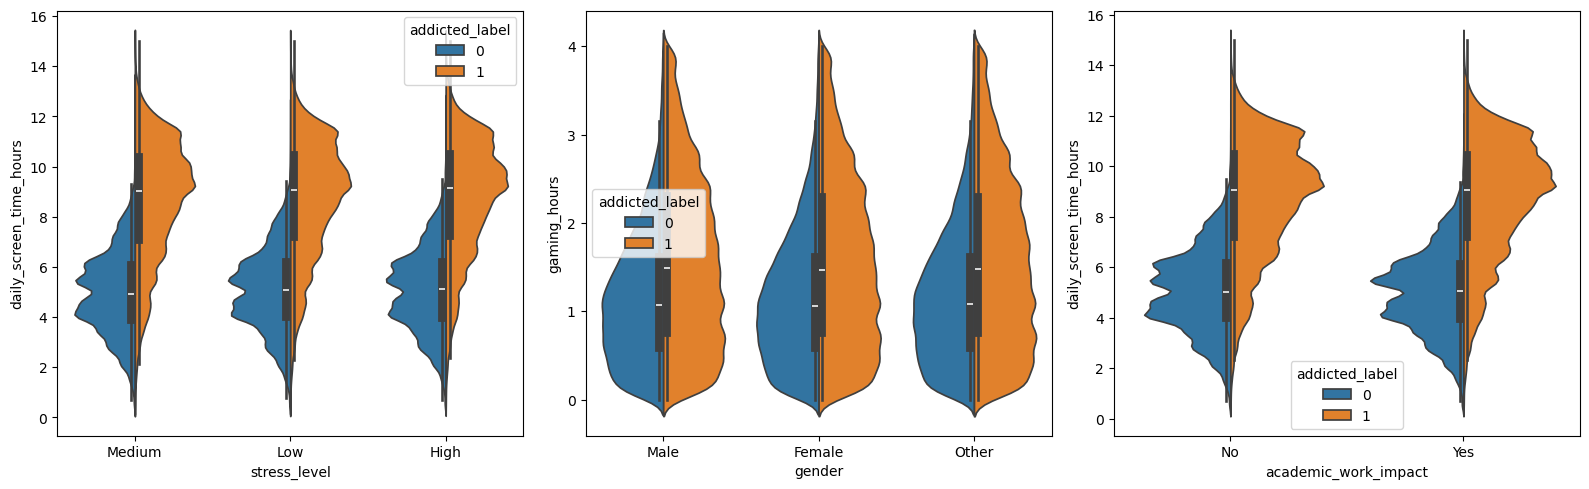

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.violinplot(x='stress_level', y='daily_screen_time_hours', hue='addicted_label',data=eda_df, split=True, ax=axes[0])
sns.violinplot(x='gender', y='gaming_hours', hue='addicted_label',data=eda_df, split=True, ax=axes[1])
sns.violinplot(x='academic_work_impact', y='daily_screen_time_hours', hue='addicted_label', data=eda_df, split=True, ax=axes[2])

plt.tight_layout()
plt.show()

As the violin plots show, there is no difference between addicted and non-addicted people in stress-level, gender or academic-work-impact. The real difference is the daily_screen_time_hours.

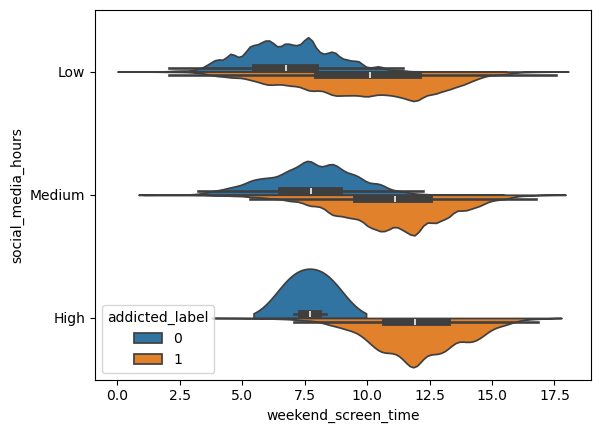

social_media_hours
Low       330079
Medium    215742
High       11553
Name: count, dtype: int64


In [12]:
bins = np.linspace(min(eda_df['social_media_hours']), max(eda_df['social_media_hours']), 4)
group_names= ['Low', 'Medium', 'High']

binned_social_media= pd.cut(eda_df['social_media_hours'], bins, labels=group_names, include_lowest=True)

sns.violinplot(x='weekend_screen_time', y=binned_social_media, hue='addicted_label', data=eda_df, split=True)
plt.show()
print(binned_social_media.value_counts().sort_index())

The plot shows that at the lower social media range the addicted labels have so much overlap, so in this range it is harder to predict the addicted label, as the social media hours rise the more separated labels occur. In high social media hours, the 0 value around 7.5-hour weekend screen time can be easily identified, and the 1 value around 12 hours (with a wider range)

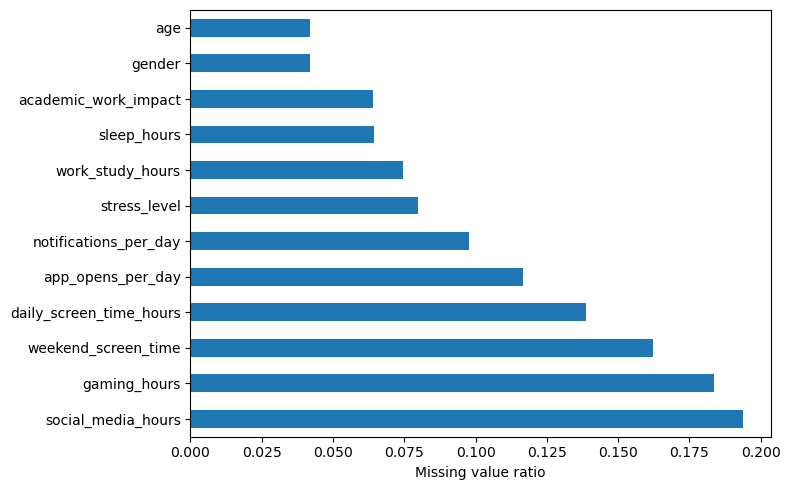

In [13]:
missing = df.isna().mean().sort_values(ascending=False)
missing[missing > 0].plot(kind='barh', figsize=(8, 5))
plt.xlabel('Missing value ratio')
plt.tight_layout()

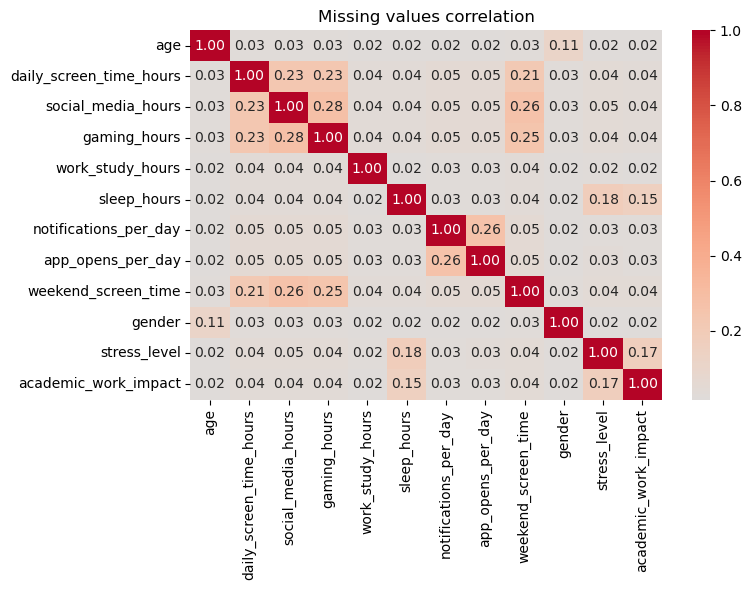

In [14]:
missing_matrix = df.isna().astype(int)
missing_matrix = missing_matrix.loc[:, missing_matrix.sum() > 0]

plt.figure(figsize=(8, 6))
sns.heatmap(missing_matrix.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Missing values correlation')
plt.tight_layout()

```python
df['weekend_screen_time_rate']= df['weekend_screen_time']/ df['daily_screen_time_hours']
df['app_time_per_open'] = df['daily_screen_time_hours'] / df['app_opens_per_day']
df['notification_per_app_open']= df['notifications_per_day'] / df['app_opens_per_day']
```
**Experiment: usage-structure ratios.** My idea was that addiction might be more about *how* someone uses the phone than how much: what share of the screen time falls on weekends, how long one app session lasts, how many notifications it takes to open an app. I built three ratio features from the existing columns and tested them with XGBoost on the full dataset.

It didn't work. ROC-AUC went down from 0.96087 to 0.95976, so the ratios added noise instead of new information. I dropped them, but I left the code here commented out.

In [15]:
def build_preprocessor(X, impute_numeric=True):
    """impute_numeric is for the XGBoost, because it can handle Nan values natively."""
    numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()
    categorical_features = X.select_dtypes(include=[object, "category"]).columns.tolist()

    if impute_numeric:
        numerical_transformer = Pipeline([
            ('imputer', SimpleImputer(strategy='mean')),
            ('scaler', StandardScaler())])
    else:
        numerical_transformer = 'passthrough'

    categorical_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))])

    return ColumnTransformer([
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)])



In [16]:

def build_pipeline(model, X, impute_numeric=True):
    return Pipeline([
        ('preprocessor', build_preprocessor(X, impute_numeric)),
        ('classifier', model)])

In [17]:

def evaluate(pipeline, X, y, cv_splits=5):
    """Out-of-fold probabilities + probability-focused metrics."""
    cv = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=42)
    y_proba = cross_val_predict(pipeline, X, y, cv=cv,
                                method='predict_proba', n_jobs=-1)[:, 1]

    print('ROC-AUC :', roc_auc_score(y, y_proba))
    print('Brier   :', brier_score_loss(y, y_proba))
    print('Log Loss:', log_loss(y, y_proba))
    draw_curve(y, y_proba)
    return y_proba

In [18]:
def draw_curve(y_set, y_proba):
    prob_true, prob_pred = calibration_curve(y_set, y_proba, n_bins=20)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 7),
                                   gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

    ax1.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect calibration')
    ax1.plot(prob_pred, prob_true, marker='o', label='Model')
    ax1.set_ylabel('True Probability')
    ax1.legend()
    ax1.grid(alpha=0.3)

    ax2.hist(y_proba, bins=20, color='steelblue')
    ax2.set_xlabel('Predicted probabilities')
    ax2.set_ylabel('Count')

    plt.tight_layout()
    plt.show()

In [19]:
X_whole= df.drop(['addicted_label', 'id'], axis=1)
y_whole= df['addicted_label']

First, I was interested in how LogisticRegression would perform with the whole dataset with filled Nan values

/var/folders/xk/7534lrcs339g13l2nj77j5bm0000gp/T/ipykernel_15567/3964073402.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=[object, "category"]).columns.tolist()


ROC-AUC : 0.9109873058599474
Brier   : 0.11191537494290575
Log Loss: 0.3467608902699185


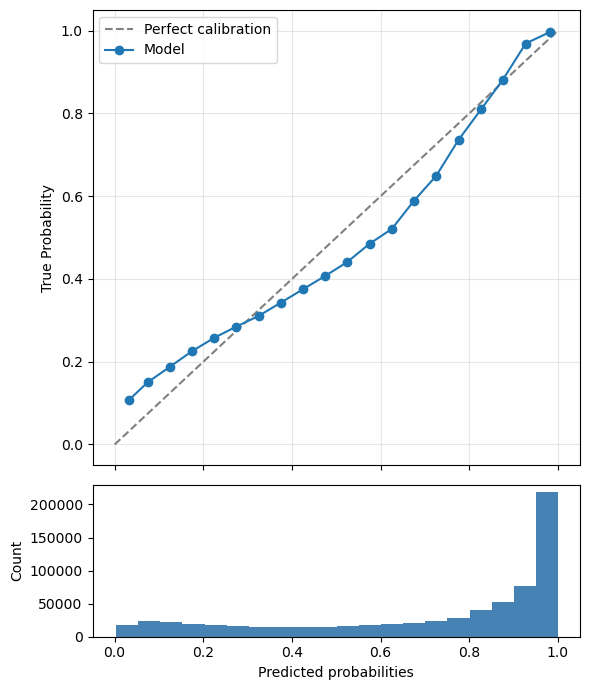

array([0.69296101, 0.43132697, 0.47202775, ..., 0.74297507, 0.97413144,
       0.32813366], shape=(691369,))

In [20]:

pipe_lr_wholeSet = build_pipeline(LogisticRegression(random_state=42), X_whole, True)
evaluate(pipe_lr_wholeSet, X_whole, y_whole)

It reached quite a good ROC-AUC score, but there's room for improvement, so in the next test, I didn't fill the missing values, I just dropped those rows.

/var/folders/xk/7534lrcs339g13l2nj77j5bm0000gp/T/ipykernel_15567/3964073402.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=[object, "category"]).columns.tolist()


ROC-AUC : 0.9276925924549926
Brier   : 0.09885410451892737
Log Loss: 0.3095198676457414


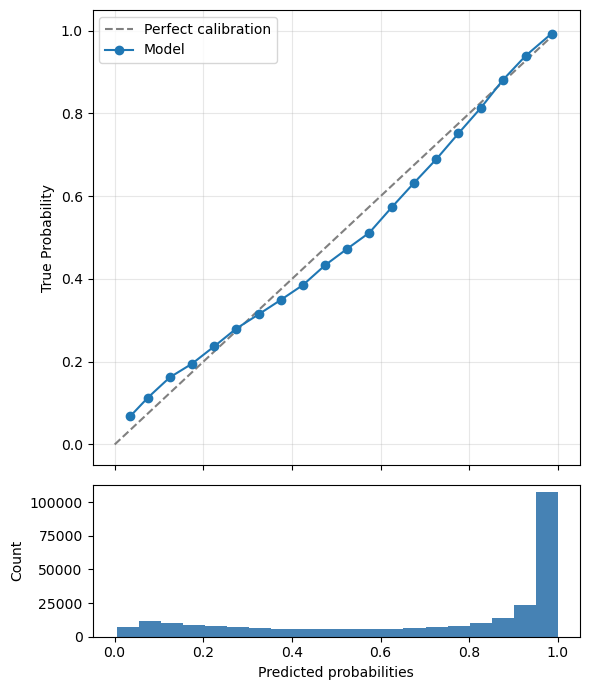

array([0.57189839, 0.31026587, 0.79887266, ..., 0.67467889, 0.99638569,
       0.47452822], shape=(269185,))

In [21]:
cleaned_df= df.dropna()

X_dropped= cleaned_df.drop(['addicted_label', 'id'], axis=1)
y_dropped= cleaned_df['addicted_label']
# model= LogisticRegression(random_state=42)
# pipeline_logReg_droppedNAN=model_prediction(model, X_dropped, y_dropped, True)

pipe_lr_droppedSet = build_pipeline(LogisticRegression(random_state=42), X_dropped, True)
evaluate(pipe_lr_droppedSet, X_dropped, y_dropped)

The full dataset run reached 0.91 ROC-AUC, but it had trouble with the 0.5–0.7 probability range. I think this is because the real relationship is a bit non-linear, and logistic regression can't capture that. Dropping the rows with missing values scored a bit better, but logistic regression doesn't need this much data to train well anyway, so the smaller dataset didn't hurt it as much as it would hurt a more data-hungry model.

***Try XGBoost for this project*** — a tree-based model that can capture non-linear relationships, unlike logistic regression.

/var/folders/xk/7534lrcs339g13l2nj77j5bm0000gp/T/ipykernel_15567/3964073402.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=[object, "category"]).columns.tolist()


ROC-AUC : 0.9605095430129652
Brier   : 0.07246407121419907
Log Loss: 0.23060902665205493


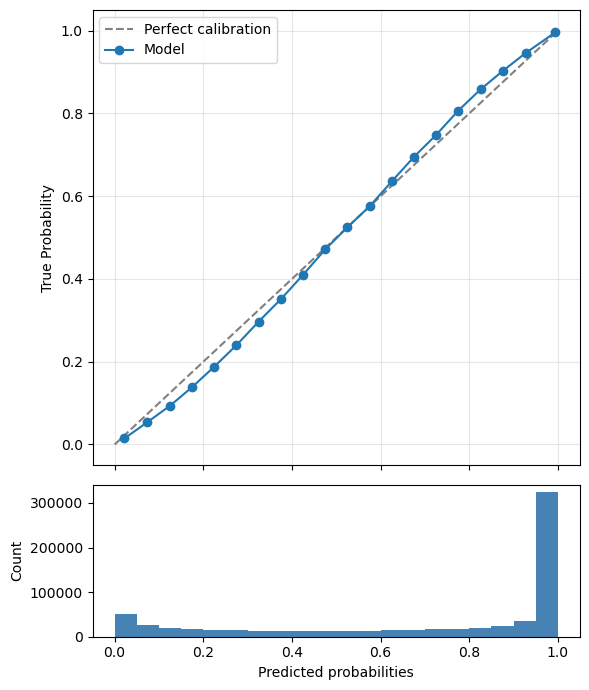

array([0.8349602 , 0.05334768, 0.45141593, ..., 0.5604501 , 0.98518515,
       0.2755541 ], shape=(691369,), dtype=float32)

In [22]:
model= xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss', random_state=42)
pipe_xgb_wholeSet=build_pipeline(model, X_whole, impute_numeric=False)
evaluate(pipe_xgb_wholeSet, X_whole, y_whole)

/var/folders/xk/7534lrcs339g13l2nj77j5bm0000gp/T/ipykernel_15567/3964073402.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=[object, "category"]).columns.tolist()


ROC-AUC : 0.9682082400331938
Brier   : 0.06459791213274002
Log Loss: 0.20754833047134175


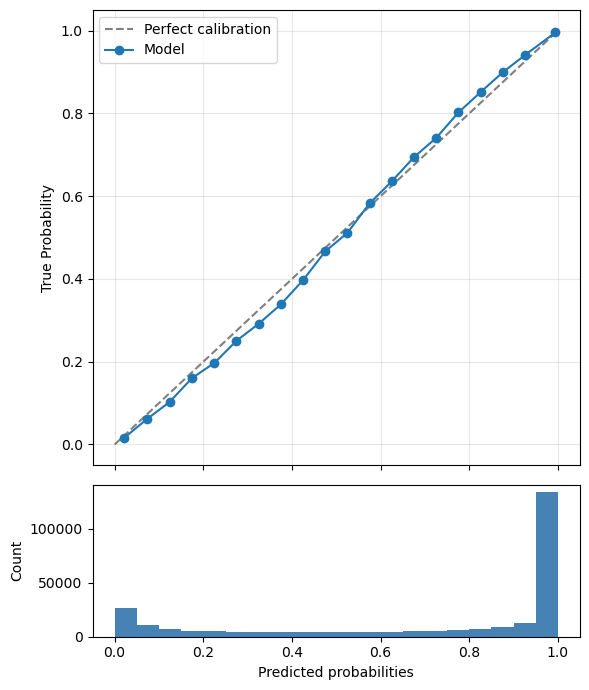

array([0.5492152 , 0.23368184, 0.3459549 , ..., 0.24454992, 0.99993587,
       0.9016287 ], shape=(269185,), dtype=float32)

In [23]:
model= xgb.XGBClassifier(
    objective='binary:logistic', 
    eval_metric='logloss',
    random_state=42)
pipeline_xgb_dropped = build_pipeline(model, X_dropped, impute_numeric=False)
evaluate(pipeline_xgb_dropped, X_dropped, y_dropped)

**Local CV said dropping the missing rows was better, the leaderboard said the opposite.**

| Setup | Local CV ROC-AUC | Public LB ROC-AUC |
|---|---|---|
| XGBoost, `dropna()` | 0.968 | 0.94899 |
| XGBoost, full dataset (native missing-value handling) | 0.959 | 0.96087 |
| XGBoost, full dataset, tuned | 0.963 | 0.96463 |

*Local CV: 5-fold on the full training data. The tuned row is the search's own 3-fold CV score on the train split, so it isn't measured exactly the same way.*

Locally the dropped version looked better, but on the leaderboard the full dataset won by a lot. It makes sense: in the test set I can't just throw away the users with missing fields, I have to give a prediction for everyone. So the model should learn on the same kind of data it will get later. Letting XGBoost handle the missing values itself generalized much better than filling them with the mean on a complete-case subset.


In [24]:
X_train, X_test, y_train, y_test= train_test_split(X_whole, y_whole, random_state=42, stratify=y_whole)
pipe_xgb_wholeSet.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [25]:
feature_importances= pipe_xgb_wholeSet['classifier'].feature_importances_
numerical_features = X_whole.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_whole.select_dtypes(include=[object, "category"]).columns.tolist()

nums= list(pipe_xgb_wholeSet['preprocessor']
                                        .named_transformers_['num']
                                        .get_feature_names_out(numerical_features))


cats=list(pipe_xgb_wholeSet['preprocessor']
                                        .named_transformers_['cat']
                                        .named_steps['onehot']
                                        .get_feature_names_out(categorical_features))
feature_names = nums + cats

importance_df= pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importances  
}).sort_values(by="Importance", ascending=False)

/var/folders/xk/7534lrcs339g13l2nj77j5bm0000gp/T/ipykernel_15567/1257653048.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_whole.select_dtypes(include=[object, "category"]).columns.tolist()


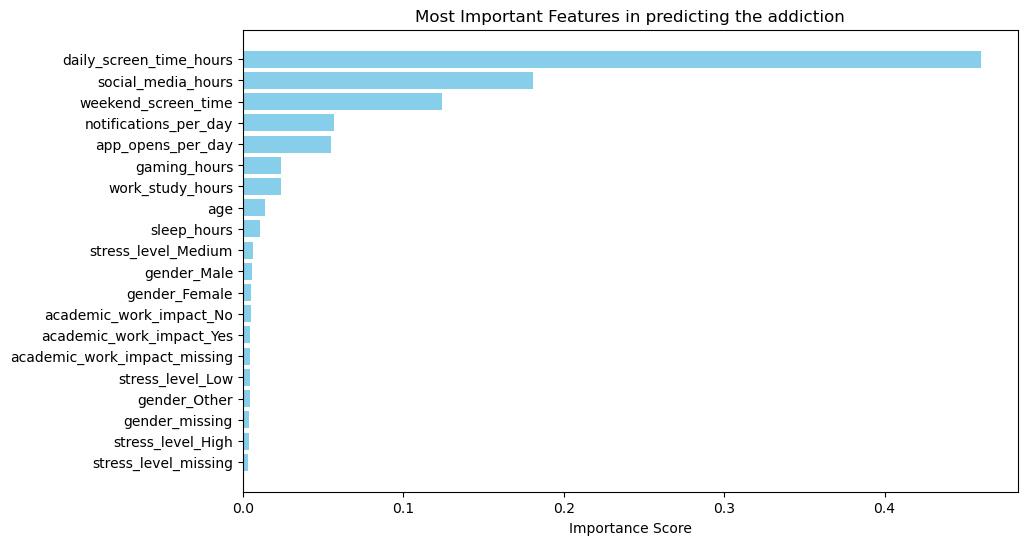

In [26]:
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
plt.gca().invert_yaxis() 
plt.title('Most Important Features in predicting the addiction')
plt.xlabel('Importance Score')
plt.show()

This confirms what I saw in the EDA: daily screen time, social media hours and weekend screen time dominate the predictions, while age, gender, stress level and academic work impact barely matter. One thing to keep in mind is that XGBoost's gain-based importance tends to understate correlated features, so I read this as a rough ranking, not an exact measure.

I ran the search twice. The first one was a wider, rougher grid; I used its results to decide where the second, narrower grid should look.

```python


param_dist = {
    'classifier__n_estimators': [500, 1000, 2000, 3000],
    'classifier__learning_rate': [0.05, 0.1, 0.17, 0.22],
    'classifier__max_depth': [3, 5, 10]
}
cv= StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
search = RandomizedSearchCV(
    pipeline, param_dist,
    n_iter=48,
    scoring='roc_auc',
    cv=StratifiedKFold(3, shuffle=True, random_state=42),
    n_jobs=-1,
    verbose=2,
    random_state=42
)
search.fit(X_train, y_train)
```


```python
param_dist = {
    'classifier__n_estimators': [3000, 4000, 5000, 6000],
    'classifier__learning_rate': [0.12, 0.15, 0.17, 0.2],
    'classifier__max_depth': [2, 3, 4],
    'classifier__min_child_weight': [1, 3, 5, 10],
    'classifier__subsample': [0.7, 0.85, 1.0],
    'classifier__colsample_bytree': [0.7, 0.85, 1.0],
}
cv= StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
search = RandomizedSearchCV(
    pipe_xgb_wholeSet,
    param_dist,
    n_iter=150,
    scoring='roc_auc',
    cv=StratifiedKFold(3, shuffle=True, random_state=42),
    n_jobs=-1,
    verbose=2,
    random_state=42
)

search.fit(X_train, y_train)
```


```python
res = pd.DataFrame(search.cv_results_)
print(search.best_score_, search.best_params_)
print(res['mean_test_score'].max() - res['mean_test_score'].min())
print(res.nlargest(10, 'mean_test_score')[['params', 'mean_test_score', 'std_test_score']])
```
***Output:***
0.9633846499829856 {'classifier__subsample': 1.0, 'classifier__n_estimators': 5000, 'classifier__min_child_weight': 10, 'classifier__max_depth': 3, 'classifier__learning_rate': 0.12, 'classifier__colsample_bytree': 1.0}
0.003080010533178079
                                                params  mean_test_score  \
46   {'classifier__subsample': 1.0, 'classifier__n_...         0.963385   
121  {'classifier__subsample': 1.0, 'classifier__n_...         0.963333   
70   {'classifier__subsample': 1.0, 'classifier__n_...         0.963332   
118  {'classifier__subsample': 1.0, 'classifier__n_...         0.963327   
74   {'classifier__subsample': 1.0, 'classifier__n_...         0.963314   
110  {'classifier__subsample': 1.0, 'classifier__n_...         0.963301   
88   {'classifier__subsample': 1.0, 'classifier__n_...         0.963286   
80   {'classifier__subsample': 1.0, 'classifier__n_...         0.963259   
14   {'classifier__subsample': 1.0, 'classifier__n_...         0.963244   
115  {'classifier__subsample': 1.0, 'classifier__n_...         0.963240   

     std_test_score  
46         0.000533  
121        0.000556  
70         0.000532  
118        0.000536  
74         0.000515  
110        0.000544  
88         0.000551  
80         0.000530  
14         0.000527  
115        0.000539

In [27]:
# Best parameters from the randomized search above
best_params = {
    'subsample': 1.0,
    'n_estimators': 5000,
    'min_child_weight': 10,
    'max_depth': 3,
    'learning_rate': 0.12,
    'colsample_bytree': 1.0,
}

final_model = xgb.XGBClassifier(objective='binary:logistic',
                                eval_metric='logloss',
                                random_state=42,
                                **best_params)

final_pipeline = build_pipeline(final_model, X_train, impute_numeric=False)
final_pipeline.fit(X_train, y_train)

/var/folders/xk/7534lrcs339g13l2nj77j5bm0000gp/T/ipykernel_15567/3964073402.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=[object, "category"]).columns.tolist()


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [28]:

prep = final_pipeline.named_steps['preprocessor']

X_sample = X_test.sample(5000, random_state=42)

X_trans = prep.transform(X_sample)
if hasattr(X_trans, 'toarray'):
    X_trans = X_trans.toarray()

feature_names = prep.get_feature_names_out()
X_shap = pd.DataFrame(X_trans, columns=feature_names)

explainer = shap.TreeExplainer(final_pipeline.named_steps['classifier'])
shap_values = explainer(X_shap)

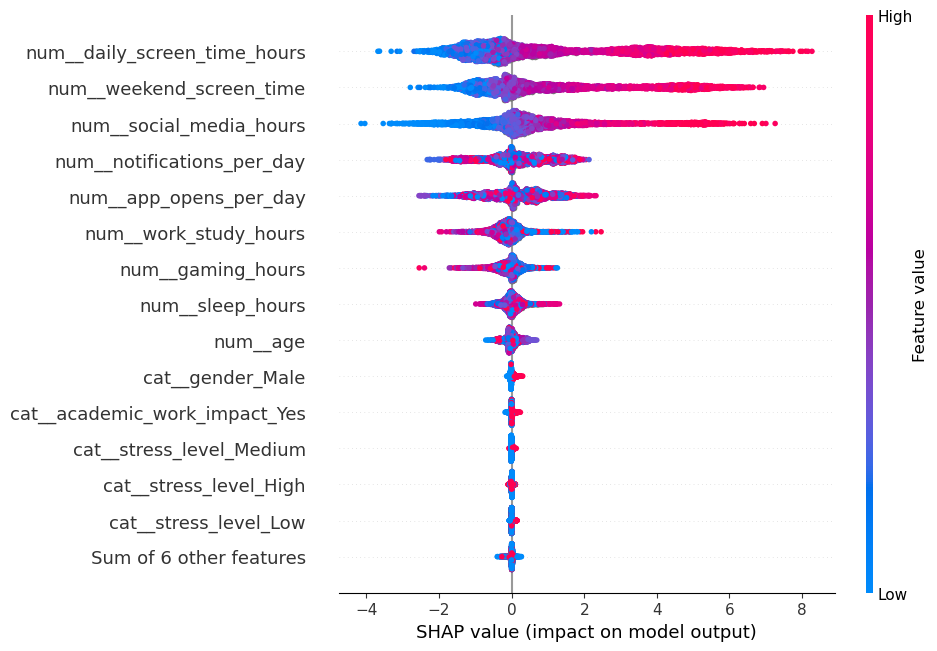

In [29]:
shap.plots.beeswarm(shap_values, max_display=15)

SHAP analysis supports the exploratory data analysis, that the 3 main features (daily_screen_time_hours, social_media_hours, weekend_screen_time) are most important in the model's output prediction. They are positively correlated with the output. However work_study_hours and gaming_hours seem to push the prediction down, meaning a lower predicted probability. This makes sense, since screen time spent on work or study is different from leisure use. SHAP also ranks notifications_per_day and app_opens_per_day as meaningful, even though the boxplots earlier showed no difference between the groups — boxplots only show each feature on its own, while SHAP shows its effect together with the other features.

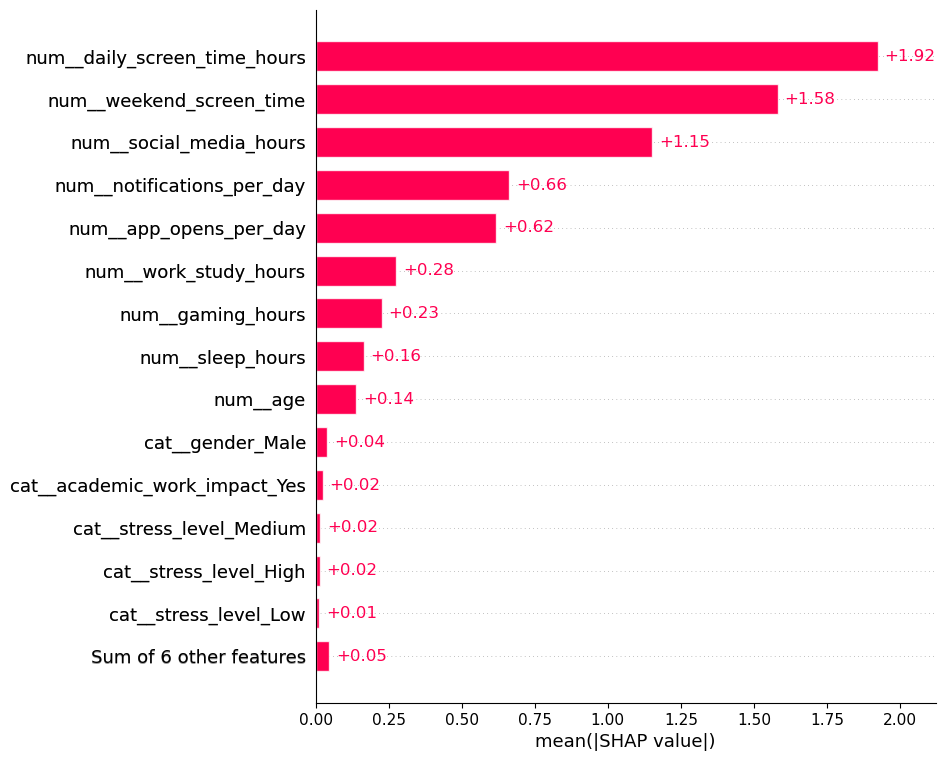

In [30]:
shap.plots.bar(shap_values, max_display=15)

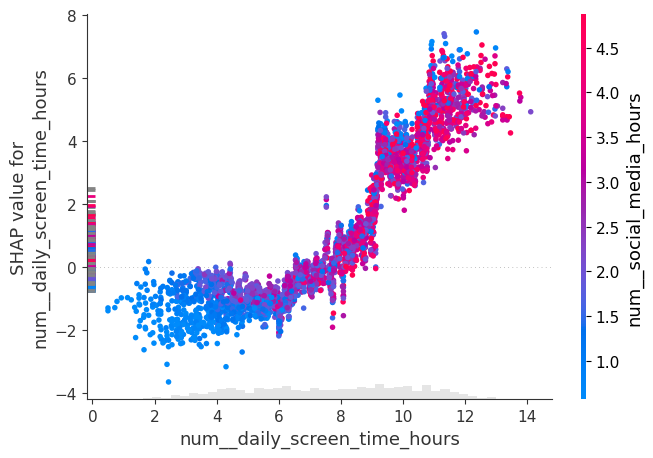

In [31]:
shap.plots.scatter(shap_values[:, 'num__daily_screen_time_hours'], color=shap_values)

In the region of 0-6 daily_screen_time_hours does not affect the model's prediction at all. As it rises, the output seems to be linear, although there is a "jump" between 8-10, probably it is because of the Decision tree's edge for the addicted_label prediction. Above 10 hours it flattens out again.

In [32]:
test_df= pd.read_csv('test.csv')
test_ids= test_df['id']

X_test_final= test_df.drop(['id'], axis=1)

proba= final_pipeline.predict_proba(X_test_final)[:, 1]

submission_df= pd.DataFrame({'id': test_ids, 'addicted_label': proba})
submission_df.to_csv('sample_submission_RandomSearch.csv', index=False)



## Summary

**Results.** The logistic regression baseline reached around 0.91 ROC-AUC. XGBoost was consistently better, and the biggest single improvement came from training on the full dataset instead of dropping the incomplete rows: 0.96087 vs 0.94899 on the leaderboard. Tuning with `RandomizedSearchCV` pushed it to **0.96463**.

**What I decided and why:**
- **Metrics:** ROC-AUC is what the competition scores, and I added log loss, Brier score and calibration curves because the output is a probability and I wanted to know if those numbers can be trusted.
- **Keep the rows with missing values:** dropping them looked better locally but was worse on the leaderboard, because the model has to predict for incomplete users too.
- **The ratio features didn't help:** I tested three of them and CV got slightly worse (0.96087 → 0.95976), so I left them out.
- **What the model uses:** daily screen time, social media hours and weekend screen time do almost all the work. SHAP also showed that the effect of daily screen time is not linear: it's flat below 6 hours, rises steeply between 6 and 10, then levels off. Interestingly, work/study hours and gaming hours push the prediction the other way.

**Limitations.** The training data only covers ages 18–35, so I wouldn't assume this works for teenagers or older adults. `addicted_label` comes with the dataset and I don't know how it was created (probably self-reported), so this is a risk score based on usage patterns, not a diagnosis.